In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install jiwer editdistance evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.0 MB/s eta 0:00:00


In [3]:
import os
import re
import itertools
import numpy as np
import pandas as pd
import torch
import evaluate
import editdistance
from datasets import Dataset, Audio
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback
)
from jiwer import wer

In [11]:
file_path = "/content/drive/MyDrive/cleaned_irbid/irbid_data.xlsx"
df = pd.read_excel(file_path)

# إعادة تسمية الأعمدة لتتوافق مع الكود
df = df.rename(columns={"audio_path": "path", "IrbidDialect": "text"})

# تحويل الـ DataFrame إلى Dataset الخاص بـ Hugging Face
dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("path", Audio(sampling_rate=16000))

# تقسيم البيانات (70% تدريب، 15% التحقق، 15% اختبار)
train_testvalid = dataset.train_test_split(test_size=0.3, seed=42)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

data_splits = {
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
}

In [12]:
model_name = "openai/whisper-large"

# إجبار الـ Processor والـ Tokenizer على اعتماد اللغة العربية والمهمة كمخرجات افتراضية
processor = WhisperProcessor.from_pretrained(model_name, language="arabic", task="transcribe")
forced_decoder_ids = processor.get_decoder_prompt_ids(language="arabic", task="transcribe")


In [13]:
def clean_arabic_text(text):
    if not isinstance(text, str) or not text:
        return ""
    # إزالة التشكيل بالكامل (فتحة، ضمة، كسرة، تنوين، شدة)
  # تصحيح النطاق: من 064B إلى 0652 لإزالة التشكيل بالكامل
    text = re.sub(r'[\u064B-\u0652]', '', text)
    text = re.sub(r'[إأآ]', 'ا', text)
    # إزالة علامات الترقيم والرموز الخاصة
    text = re.sub(r'[^\w\s\s]', '', text)
    # تنظيف المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prepare_example(batch):
    audio_data = batch["path"]

    # استخراج الميزات الصوتية
    audio_features = []
    for x in audio_data:
        raw_audio = x["array"]
        feature = processor(raw_audio, sampling_rate=16000).input_features[0]
        audio_features.append(feature)

    # تحديد عمود النص وتطبيق دالة التنظيف قبل التوكينايزر
    text_column = "text"
    cleaned_texts = [clean_arabic_text(t) for t in batch[text_column]]

    # تحويل النصوص المنظفة إلى Token IDs
    text_labels = [
        processor.tokenizer(t).input_ids
        for t in cleaned_texts
    ]

    return {"input_features": audio_features, "labels": text_labels}




In [8]:
save_folder = "/content/drive/MyDrive/pro_data/processed_irbid_datasetsss"
os.makedirs(save_folder, exist_ok=True)

In [15]:
import os
file_path = "/content/drive/MyDrive/cleaned_irbid/audio/521.wav"

if os.path.exists(file_path):
    print("✅ الملف موجود، قد تكون المشكلة في الصلاحيات.")
else:
    print("❌ الملف غير موجود فعلياً في هذا المسار! تأكد من الاسم والمجلد.")

✅ الملف موجود، قد تكون المشكلة في الصلاحيات.


In [14]:
# تطبيق المعالجة على كافة الانقسامات (Splits)
for split in ['train', 'validation', 'test']:
    cols_to_remove = data_splits[split].column_names
    data_splits[split] = data_splits[split].map(
        prepare_example,
        batched=True,
        remove_columns=cols_to_remove,
        batch_size=8
    )

    split_save_path = os.path.join(save_folder, split)

    # 3. الحفظ الآمن على الدرايف باستخدام save_to_disk
    print(f"💾 {split} ")
    data_splits[split].save_to_disk(split_save_path)

    print(f"✅{split_save_path}\n")


Map:   0%|          | 0/1050 [00:00<?, ? examples/s]

💾 train 


Saving the dataset (0/3 shards):   0%|          | 0/1050 [00:00<?, ? examples/s]

✅/content/drive/MyDrive/pro_data/processed_irbid_datasetsss/train



Map:   0%|          | 0/225 [00:00<?, ? examples/s]

...

✅/content/drive/MyDrive/pro_data/processed_irbid_datasetsss/validation



Map:   0%|          | 0/225 [00:00<?, ? examples/s]

💾 test 


Saving the dataset (0/1 shards):   0%|          | 0/225 [00:00<?, ? examples/s]

✅/content/drive/MyDrive/pro_data/processed_irbid_datasetsss/test



In [16]:
from datasets import load_from_disk
import os

save_folder =  "/content/drive/MyDrive/pro_data/processed_irbid_datasetsss"

# 2. تحميل البيانات الجاهزة فوراً
train_dataset = load_from_disk(os.path.join(save_folder, 'train'))
val_dataset   = load_from_disk(os.path.join(save_folder, 'validation'))
test_dataset  = load_from_disk(os.path.join(save_folder, 'test'))

print(train_dataset)

Dataset({
    features: ['input_features', 'labels'],
    num_rows: 1050
})


In [18]:
@dataclass
class DataCollatorWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # حشو الميزات الصوتية
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        if batch["input_features"].ndim == 4:
            batch["input_features"] = batch["input_features"].squeeze(1)

        # حشو النصوص (Labels)
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # استبدال الـ padding بـ -100 لحساب الـ loss بشكل صحيح وإهمال الحشو
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch

data_collator = DataCollatorWithPadding(processor=processor)

In [19]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # استبدال الـ -100 بـ pad_token_id لكي لا تحدث أخطاء أثناء التفكيك
    labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)

    # تحويل الـ IDs إلى نصوص عربية حقيقية
    pred_str = processor.tokenizer.batch_decode(predictions, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

    # حساب المقاييس
    wer_score = wer_metric.compute(predictions=pred_str, references=label_str)
    cer_score = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer_score * 100, "cer": cer_score * 100}

In [20]:
num_epochs = 5
learning_rates = [1e-5]
batch_sizes = [8]
optimizers = ["adafactor"]  # تم الإبقاء على المحسنات المستقرة والمدعومة فقط

best_wer = float("inf")
best_config = None

for lr, bs, opt in itertools.product(learning_rates, batch_sizes, optimizers):
    print(f"\n=====   LR={lr}, Batch={bs}, Optimizer={opt} =====")

    # ضبط الـ Gradient Accumulation بناءً على حجم الـ Batch لحفظ الذاكرة
    grad_accum = 2 if bs < 16 else 1

    # تحميل الموديل وضبط إعداداته لمنع التعارض والهلوسة
    model = WhisperForConditionalGeneration.from_pretrained(model_name)

    # 1. الـ use_cache خاص بالتدريب ويبقى في الـ config الرئيسي
    model.config.use_cache = False

    # 2. إعدادات التوليد ننقلها إلى الـ generation_config لمنع الـ ValueError
    model.generation_config.forced_decoder_ids = forced_decoder_ids
    model.generation_config.suppress_tokens = []

    training_args = Seq2SeqTrainingArguments(
        output_dir="./whisper_irbid_tuning",
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=max(1, bs // 2),
        gradient_accumulation_steps=grad_accum,
        eval_strategy="steps",
        num_train_epochs=num_epochs,
        save_steps=100,
        save_total_limit=1,
        logging_steps=50,
        learning_rate=lr,
        fp16=torch.cuda.is_available(),
        optim=opt,
        report_to="none",
        predict_with_generate=True,
        generation_max_length=225,
        load_best_model_at_end=True,
        metric_for_best_model="wer",
        greater_is_better=False,
        save_strategy="steps",
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset ,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # التقييم على الـ Validation Set لهذه التجربة
    metrics = trainer.evaluate()
    val_wer = metrics.get("eval_wer", float("inf"))
    val_loss = metrics.get("eval_loss", float("inf"))

    print(f"-> تم الانتهاء من هذه التجربة.")
    print(f"   Validation Loss: {val_loss:.8f} | Validation WER: {val_wer:.2f}%")

    # حفظ أفضل موديل بناءً على أقل معدل خطأ (WER)
    if val_wer < best_wer:
        best_wer = val_wer
        best_config = (lr, bs, opt)
        trainer.save_model("./best_whisperlarge_irbid_1e_8_adaaa")
        processor.save_pretrained("./best_whisperlarge_irbid_1e_8_adaaa")

print("\n✅ Hyperparameters ")
print(f"Learning Rate: {best_config[0]} | Batch Size: {best_config[1]} | Optimizer: {best_config[2]}")
print(f"Best Validation WER: {best_wer:.2f}%")


=====   LR=1e-05, Batch=8, Optimizer=adafactor =====


model.safetensors:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

Step,Training Loss,Validation Loss,Wer,Cer
50,1.625178,0.320849,27.968750,11.842105
100,0.380733,0.311972,28.515625,11.981424
150,0.198512,0.318424,25.156250,10.804954
200,0.092494,0.318872,24.843750,10.603715
250,0.036761,0.312164,24.140625,10.216718
300,0.011987,0.324457,23.203125,9.938080


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


-> تم الانتهاء من هذه التجربة.
   Validation Loss: 0.32445687 | Validation WER: 23.20%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Hyperparameters 
Learning Rate: 1e-05 | Batch Size: 8 | Optimizer: adafactor
Best Validation WER: 23.20%


In [21]:
print("\n(Test Set)...")

device = "cuda" if torch.cuda.is_available() else "cpu"

# إعادة تحميل النموذج الأفضل والـ processor المحفوظ
model_path = "./best_whisperlarge_irbid_1e_8_adaaa"
best_model = WhisperForConditionalGeneration.from_pretrained(model_path).to(device)
best_processor = WhisperProcessor.from_pretrained(model_path)

best_model.eval()
test_dataset = test_dataset

predictions = []

for sample in test_dataset:
    inputs = torch.tensor(sample["input_features"]).unsqueeze(0).to(device)

    with torch.no_grad():
        # تمرير قيم اللغة والمهمة صراحة أثناء الـ generate كأمان لمنع الهلوسة
        predicted_ids = best_model.generate(
            inputs,
            language="arabic",
            task="transcribe"
        )

    transcription = best_processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    reference = best_processor.tokenizer.decode(sample["labels"], skip_special_tokens=True)

    # تطبيق دالة التنظيف على المخرجات النهائية أيضاً لضمان عدالة الحساب ومقارنة الحروف الصحيحة
    predictions.append({
        "reference": clean_arabic_text(reference),
        "prediction": clean_arabic_text(transcription)
    })

# حساب مقاييس الـ Test النهائية بالـ jiwer و editdistance
final_references = [p["reference"] for p in predictions]
final_hypotheses = [p["prediction"] for p in predictions]

test_wer_score = wer(final_references, final_hypotheses)
total_cer = sum(editdistance.eval(r, h) for r, h in zip(final_references, final_hypotheses))
total_chars = sum(len(r) for r in final_references) if sum(len(r) for r in final_references) > 0 else 1
test_cer_score = total_cer / total_chars

print(f"\n ")
print(f" WER على Test set: {test_wer_score * 100:.2f}%")
print(f" CER على Test set: {test_cer_score * 100:.2f}%")

# حفظ ملف المخرجات للمعاينة البشرية
pd.DataFrame(predictions).to_csv("whisper_large_irbid_1e_8_adaaa_test_results.csv", index=False)
print("✅ whisper_large_irbid_1e_8_adaaa_test_results.csv")


(Test Set)...


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]


 
 WER على Test set: 23.87%
 CER على Test set: 7.99%
✅ whisper_large_irbid_1e_8_adaaa_test_results.csv


In [22]:
import shutil
from google.colab import drive

# 2️⃣ تحديد المجلد المصدر والمجلد الهدف في Drive
source_folder = "./best_whisperlarge_irbid_1e_8_adaaa"  # مجلد الموديل المحفوظ محلياً
target_folder = "/content/drive/MyDrive/whisper_large_irbid_1e_8_adaaa_test_results_saved"  # المكان في Drive

# 3️⃣ نسخ المجلد بالكامل إلى Drive
shutil.copytree(source_folder, target_folder)

print(f"✅ تم حفظ المجلد بالكامل في Google Drive: {target_folder}")

✅ تم حفظ المجلد بالكامل في Google Drive: /content/drive/MyDrive/whisper_large_irbid_1e_8_adaaa_test_results_saved


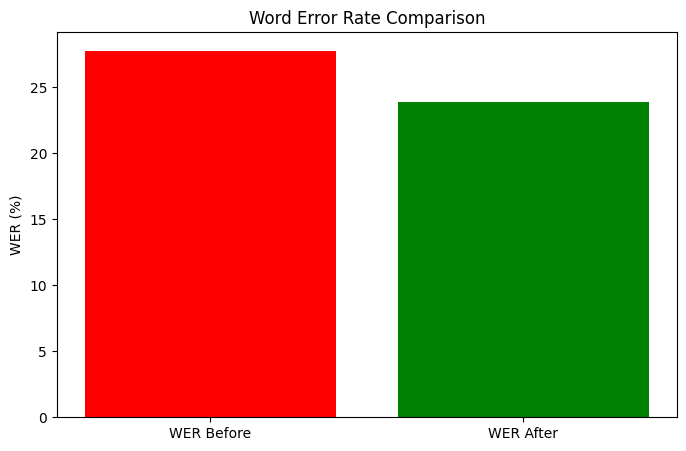

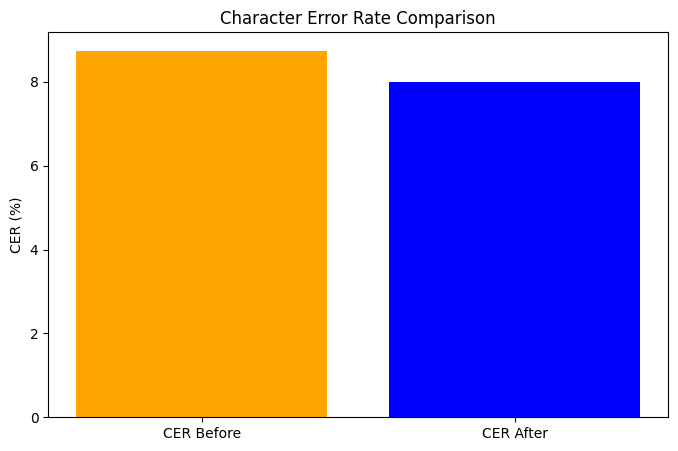

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from jiwer import wer
import editdistance

# قراءة النتائج
before_df = pd.read_csv("/content/drive/MyDrive/whisper_med_without_training_results.csv")
after_df = pd.read_csv("whisper_large_irbid_1e_8_adaaa_test_results.csv")

# حساب WER و CER لكل مجموعة
def compute_metrics(df):
    refs = df["reference"].tolist()
    preds = df["prediction"].tolist()
    wer_score = wer(refs, preds)
    total_cer = sum(editdistance.eval(r, p) for r, p in zip(refs, preds))
    total_chars = sum(len(r) for r in refs)
    cer_score = total_cer / total_chars
    return wer_score*100, cer_score*100

wer_before, cer_before = compute_metrics(before_df)
wer_after, cer_after = compute_metrics(after_df)

# رسم المقارنة
plt.figure(figsize=(8,5))
plt.bar(["WER Before","WER After"], [wer_before, wer_after], color=["red","green"])
plt.title("Word Error Rate Comparison")
plt.ylabel("WER (%)")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(["CER Before","CER After"], [cer_before, cer_after], color=["orange","blue"])
plt.title("Character Error Rate Comparison")
plt.ylabel("CER (%)")
plt.show()

In [24]:

# تأكد أن المجلد موجود، وإن لم يكن موجودًا سيتم إنشاؤه
save_folder = "/content/drive/MyDrive/whisper_large_irbid_1e_8_adaaa_test_results_saved"


# تحديد مسار الملف داخل المجلد
save_path = os.path.join(save_folder, "whisper_large_irbid_1e_8_adaaa_test_results.csv")

# حفظ الملف
pd.DataFrame(predictions).to_csv(save_path, index=False)

print(f"✅ الملف تم حفظه هنا: {save_path}")


✅ الملف تم حفظه هنا: /content/drive/MyDrive/whisper_large_irbid_1e_8_adaaa_test_results_saved/whisper_large_irbid_1e_8_adaaa_test_results.csv
